# Little 500 2026 — XGBoost Prediction Pipeline

**Women's race:** Apr 24 | **Men's race:** Apr 25  
**Inputs:** `little500_2026_men_xgb.csv` and `little500_2026_women_xgb.csv`  
**Targets:** Ordinal finish rank (regressor) + top-5 flag (classifier)  

After the races, fill `actual_finish_2026` in the CSVs and run Section 10 to evaluate.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import warnings
warnings.filterwarnings('ignore')

from xgboost import XGBRegressor, XGBClassifier
from sklearn.model_selection import LeaveOneOut, cross_val_score, GridSearchCV
from sklearn.metrics import mean_absolute_error, accuracy_score
import shap

MEN_CSV   = 'little500_2026_men_xgb.csv'
WOMEN_CSV = 'little500_2026_women_xgb.csv'
SEED = 42

## 1. Load

In [2]:
df_m = pd.read_csv(MEN_CSV)
df_w = pd.read_csv(WOMEN_CSV)

print(f"Men:   {df_m.shape[0]} teams, {df_m.shape[1]} columns")
print(f"Women: {df_w.shape[0]} teams, {df_w.shape[1]} columns")

# All columns except identifiers and target are features
SKIP = {'team', 'actual_finish_2026'}
FEATURES_M = [c for c in df_m.columns if c not in SKIP]
FEATURES_W = [c for c in df_w.columns if c not in SKIP]

print(f"\nMen features ({len(FEATURES_M)}): {FEATURES_M}")
print(f"\nWomen features ({len(FEATURES_W)}): {FEATURES_W}")

Men:   33 teams, 32 columns
Women: 33 teams, 31 columns

Men features (30): ['qual_pos', 'qual_time_sec', 'qual_time_norm', 'itt_best_rider_rank_imputed', 'itt_best_rank_norm', 'itt_rank_is_estimated', 'itt_riders_top40', 'mno_reached_final', 'mno_reached_semis', 'team_pursuit_pos_filled', 'team_pursuit_time_sec', 'spring_series_winner', 'spring_series_score', 'hist_races', 'hist_wins', 'hist_win_rate', 'hist_top3_rate', 'hist_top5_rate', 'hist_avg_finish_all', 'hist_avg_finish_5yr', 'hist_avg_finish_3yr', 'hist_best_finish', 'hist_last_finish', 'hist_years_since_last_race', 'hist_years_since_last_win', 'hist_consecutive_top5', 'hist_trend_3yr', 'hist_is_first_year', 'defending_champ', 'team_type_enc']

Women features (29): ['qual_pos', 'qual_time_sec', 'qual_time_norm', 'itt_best_rider_rank_imputed', 'itt_best_rank_norm', 'itt_rank_is_estimated', 'mno_reached_final', 'mno_reached_semis', 'team_pursuit_pos_filled', 'team_pursuit_time_sec', 'spring_series_winner', 'spring_series_score',

In [3]:
# Null check
m_nulls = df_m[FEATURES_M].isnull().sum()
w_nulls = df_w[FEATURES_W].isnull().sum()
print('Men nulls:',   m_nulls[m_nulls > 0].to_dict() or 'None')
print('Women nulls:', w_nulls[w_nulls > 0].to_dict() or 'None')

Men nulls: None
Women nulls: None


## 2. Targets

- **`target_rank`** — rank of `spring_series_score` (lower score = better predicted finish)
- **`target_top5`** — 1 if `hist_avg_finish_5yr <= 4.5` (historically a top-5 program)

After the race: swap in `actual_finish_2026` as the real target and retrain.

In [4]:
for df, label in [(df_m, 'Men'), (df_w, 'Women')]:
    df['target_rank'] = df['spring_series_score'].rank(method='min').astype(int)
    df['target_top5'] = (df['hist_avg_finish_5yr'] <= 4.5).astype(int)
    n_top5 = df['target_top5'].sum()
    teams  = df[df['target_top5'] == 1]['team'].tolist()
    print(f"{label} — {n_top5} top-5 candidates: {teams}")

Men — 11 top-5 candidates: ['Cutters', 'Sigma Alpha Epsilon', 'Phi Gamma Delta', 'Sigma Phi Epsilon', 'Black Key Bulls', 'Bears Cycling', 'Sigma Nu', 'Cinzano', 'Delta Tau Delta', 'Phi Delta Theta', 'Acacia']
Women — 10 top-5 candidates: ['Kappa Alpha Theta', 'Teter', 'Alpha Chi Omega', 'Delta Gamma', 'Melanzana Cycling', 'Kappa Kappa Gamma', 'Kappa Delta', 'Novus (W)', 'Pi Beta Phi', 'Alpha Omicron Pi']


## 3. EDA

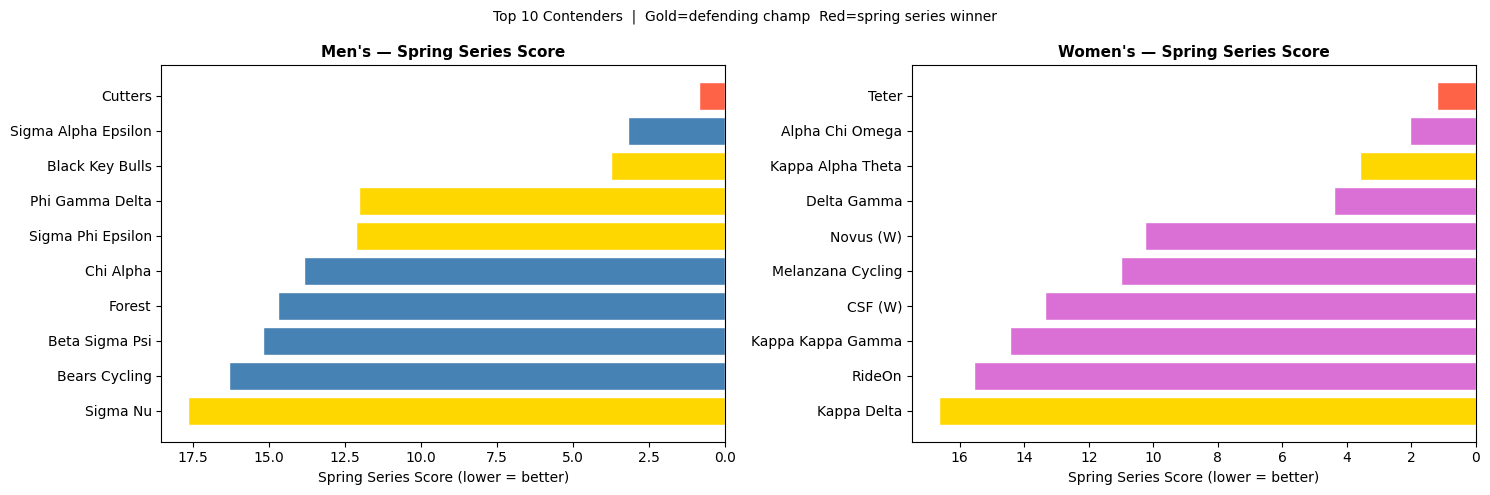

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for ax, df, title, base_color in [
    (axes[0], df_m, "Men's — Spring Series Score",   'steelblue'),
    (axes[1], df_w, "Women's — Spring Series Score", 'orchid'),
]:
    top10 = df.nsmallest(10, 'spring_series_score')
    colors = [
        'gold'   if d else
        'tomato' if s else
        base_color
        for d, s in zip(top10['defending_champ'], top10['spring_series_winner'])
    ]
    ax.barh(top10['team'][::-1], top10['spring_series_score'][::-1],
            color=colors[::-1], edgecolor='white')
    ax.set_xlabel('Spring Series Score (lower = better)')
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.invert_xaxis()

fig.suptitle('Top 10 Contenders  |  Gold=defending champ  Red=spring series winner', fontsize=10)
plt.tight_layout()
plt.savefig('spring_series_scores.png', dpi=150, bbox_inches='tight')
plt.show()

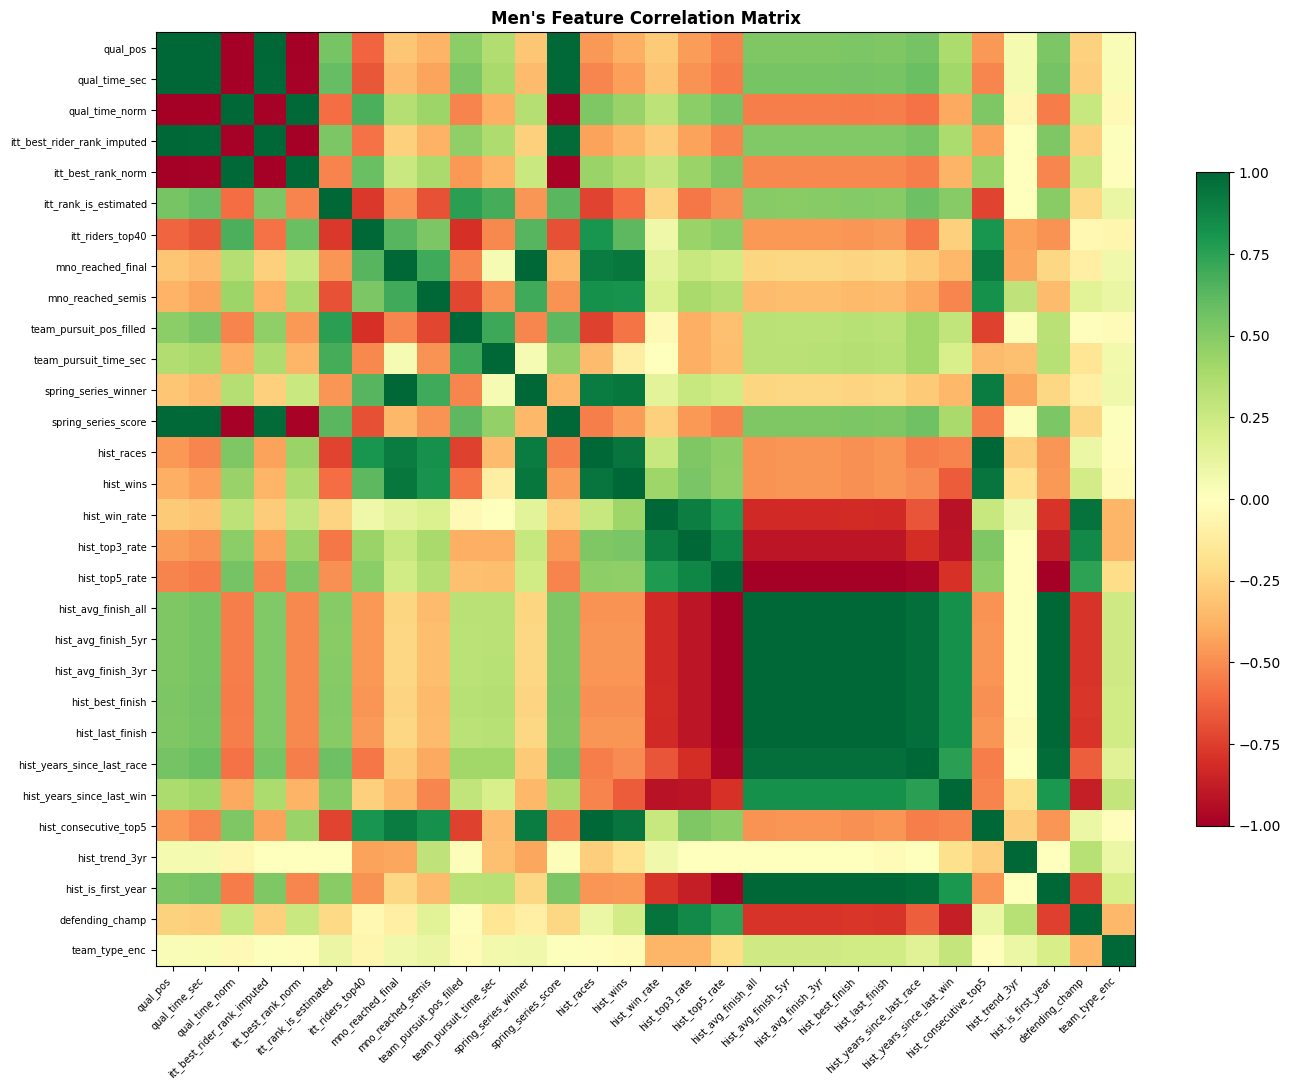

In [6]:
# Correlation heatmap — men
corr = df_m[FEATURES_M].corr()
fig, ax = plt.subplots(figsize=(14, 11))
im = ax.imshow(corr.values, cmap='RdYlGn', vmin=-1, vmax=1, aspect='auto')
plt.colorbar(im, ax=ax, shrink=0.7)
ax.set_xticks(range(len(FEATURES_M)))
ax.set_yticks(range(len(FEATURES_M)))
ax.set_xticklabels(FEATURES_M, rotation=45, ha='right', fontsize=7)
ax.set_yticklabels(FEATURES_M, fontsize=7)
ax.set_title("Men's Feature Correlation Matrix", fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_men.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Model A — XGBRegressor (Finish Rank)


In [18]:
def run_regressor(df, features, name):
    X = df[features].values
    y = df['target_rank'].values

    model = XGBRegressor(
        n_estimators=200,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.7,
        min_child_weight=2,
        reg_alpha=0.5,
        reg_lambda=2.0,
        random_state=SEED,
        verbosity=0,
    )

    loo = cross_val_score(model, X, y, cv=LeaveOneOut(),
                          scoring='neg_mean_absolute_error')
    print(f"{name} Regressor LOO MAE: {-loo.mean():.2f} +/- {loo.std():.2f} positions")

    model.fit(X, y)
    df = df.copy()
    df['reg_score'] = model.predict(X)
    df['reg_rank']  = df['reg_score'].rank(method='min').astype(int)
    return model, df


model_m_reg, df_m = run_regressor(df_m, FEATURES_M, "Men's")
model_w_reg, df_w = run_regressor(df_w, FEATURES_W, "Women's")

Men's Regressor LOO MAE: 1.01 +/- 0.84 positions
Women's Regressor LOO MAE: 1.04 +/- 0.81 positions


In [20]:
print("=== MEN'S — Predicted Finish Order ===")
print(
    df_m[['team','reg_rank','qual_pos','spring_series_score',
          'hist_wins','hist_avg_finish_5yr','defending_champ']]
    .sort_values('reg_rank')
    .to_string(index=False)
)

=== MEN'S — Predicted Finish Order ===
               team  reg_rank  qual_pos  spring_series_score  hist_wins  hist_avg_finish_5yr  defending_champ
            Cutters         1         1                 0.85         15                  2.0                0
Sigma Alpha Epsilon         2         2                 3.20          0                  2.2                0
    Black Key Bulls         3         5                 3.75          4                  2.2                1
    Phi Gamma Delta         4         3                12.05          2                  1.0                1
  Sigma Phi Epsilon         5         4                12.15          2                  1.0                1
          Chi Alpha         6         6                13.85          0                 25.0                0
             Forest         7        12                14.70          0                 25.0                0
     Beta Sigma Psi         8         7                15.20          0          

In [21]:
print("=== WOMEN'S — Predicted Finish Order ===")
print(
    df_w[['team','reg_rank','qual_pos','spring_series_score',
          'hist_wins','hist_avg_finish_5yr','defending_champ']]
    .sort_values('reg_rank')
    .to_string(index=False)
)

=== WOMEN'S — Predicted Finish Order ===
             team  reg_rank  qual_pos  spring_series_score  hist_wins  hist_avg_finish_5yr  defending_champ
            Teter         1         2                 1.20          4                  2.6                0
  Alpha Chi Omega         2         3                 2.05          0                  2.5                0
Kappa Alpha Theta         3         1                 3.60         10                  1.6                1
      Delta Gamma         4         4                 4.40          4                  3.6                0
        Novus (W)         5        10                10.25          0                  3.0                0
Melanzana Cycling         6         5                11.00          2                  3.0                0
          CSF (W)         7         6                13.35          0                 19.0                0
Kappa Kappa Gamma         8         7                14.45          5                  2.0     

## 5. Model B — XGBClassifier (Top-5 Probability)

In [22]:
def run_classifier(df, features, name):
    X = df[features].values
    y = df['target_top5'].values

    model = XGBClassifier(
        n_estimators=200,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.7,
        min_child_weight=2,
        reg_alpha=0.5,
        reg_lambda=2.0,
        eval_metric='logloss',
        random_state=SEED,
        verbosity=0,
    )

    loo = cross_val_score(model, X, y, cv=LeaveOneOut(), scoring='accuracy')
    print(f"{name} Classifier LOO Accuracy: {loo.mean():.3f}")

    model.fit(X, y)
    df = df.copy()
    df['top5_prob'] = model.predict_proba(X)[:, 1]
    df['clf_rank']  = df['top5_prob'].rank(ascending=False, method='min').astype(int)
    return model, df


model_m_clf, df_m = run_classifier(df_m, FEATURES_M, "Men's")
model_w_clf, df_w = run_classifier(df_w, FEATURES_W, "Women's")

Men's Classifier LOO Accuracy: 0.970
Women's Classifier LOO Accuracy: 0.909


In [23]:
print("=== MEN'S — Top-5 Probability ===")
print(df_m[['team','top5_prob','clf_rank','qual_pos']]
      .sort_values('clf_rank').head(15).to_string(index=False))

=== MEN'S — Top-5 Probability ===
               team  top5_prob  clf_rank  qual_pos
            Cutters   0.784567         1         1
    Black Key Bulls   0.784567         1         5
  Sigma Phi Epsilon   0.784567         1         4
           Sigma Nu   0.784567         1         9
Sigma Alpha Epsilon   0.784567         1         2
    Phi Gamma Delta   0.784567         1         3
            Cinzano   0.778134         7        10
    Delta Tau Delta   0.734160         8        20
    Phi Delta Theta   0.727740         9        21
             Acacia   0.727740         9        30
      Bears Cycling   0.725531        11         8
        CSF Cycling   0.292020        12        11
          Chi Alpha   0.135957        13         6
     Beta Sigma Psi   0.135957        13         7
             Forest   0.132676        15        12


In [24]:
print("=== WOMEN'S — Top-5 Probability ===")
print(df_w[['team','top5_prob','clf_rank','qual_pos']]
      .sort_values('clf_rank').head(15).to_string(index=False))

=== WOMEN'S — Top-5 Probability ===
             team  top5_prob  clf_rank  qual_pos
Kappa Alpha Theta   0.757669         1         1
            Teter   0.757669         1         2
  Alpha Chi Omega   0.757669         1         3
      Delta Gamma   0.757669         1         4
        Novus (W)   0.757669         1        10
Kappa Kappa Gamma   0.757669         1         7
Melanzana Cycling   0.748461         7         5
      Kappa Delta   0.743855         8         9
      Pi Beta Phi   0.674120         9        17
 Alpha Omicron Pi   0.618578        10        23
          CSF (W)   0.411979        11         6
     SALT Cycling   0.162753        12        11
           RideOn   0.162753        12         8
   Alpha Delta Pi   0.150708        14        12
      Sigma Kappa   0.113956        15        13


## 6. Ensemble & Final Predictions

In [25]:
def make_final(df, label):
    df = df.copy()
    df['ensemble_rank'] = (
        df['reg_rank'] * 0.5 + df['clf_rank'] * 0.5
    ).rank(method='min').astype(int)

    out = (
        df[['team','ensemble_rank','reg_rank','clf_rank','top5_prob',
            'qual_pos','spring_series_score','hist_wins',
            'hist_avg_finish_5yr','defending_champ']]
        .sort_values('ensemble_rank')
        .reset_index(drop=True)
    )

    print(f"\n{'='*65}")
    print(f"  {label} — FINAL ENSEMBLE PREDICTIONS")
    print(f"{'='*65}")
    print(out.to_string(index=False))
    return df, out


df_m, men_final   = make_final(df_m, "MEN'S RACE")
df_w, women_final = make_final(df_w, "WOMEN'S RACE")


  MEN'S RACE — FINAL ENSEMBLE PREDICTIONS
               team  ensemble_rank  reg_rank  clf_rank  top5_prob  qual_pos  spring_series_score  hist_wins  hist_avg_finish_5yr  defending_champ
            Cutters              1         1         1   0.784567         1                 0.85         15                  2.0                0
Sigma Alpha Epsilon              2         2         1   0.784567         2                 3.20          0                  2.2                0
    Black Key Bulls              3         3         1   0.784567         5                 3.75          4                  2.2                1
    Phi Gamma Delta              4         4         1   0.784567         3                12.05          2                  1.0                1
  Sigma Phi Epsilon              5         5         1   0.784567         4                12.15          2                  1.0                1
           Sigma Nu              6        10         1   0.784567         9      

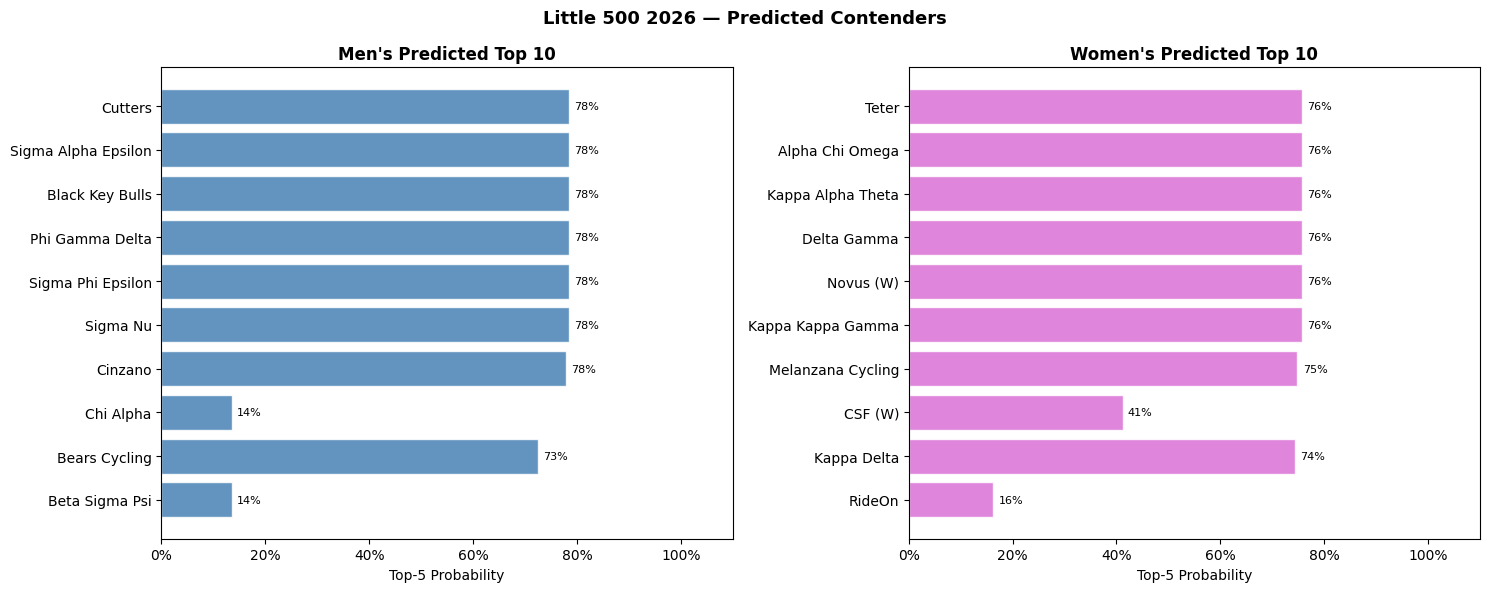

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

for ax, final, title, color in [
    (axes[0], men_final.head(10),   "Men's Predicted Top 10",   'steelblue'),
    (axes[1], women_final.head(10), "Women's Predicted Top 10", 'orchid'),
]:
    bars = ax.barh(
        final['team'][::-1],
        final['top5_prob'][::-1],
        color=color, alpha=0.85, edgecolor='white',
    )
    ax.set_xlabel('Top-5 Probability')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.xaxis.set_major_formatter(ticker.PercentFormatter(xmax=1))
    ax.set_xlim(0, 1.1)
    for bar, prob in zip(bars, final['top5_prob'][::-1]):
        ax.text(bar.get_width() + 0.01,
                bar.get_y() + bar.get_height() / 2,
                f'{prob:.0%}', va='center', fontsize=8)

fig.suptitle('Little 500 2026 — Predicted Contenders', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('little500_2026_predictions.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. SHAP Feature Importance

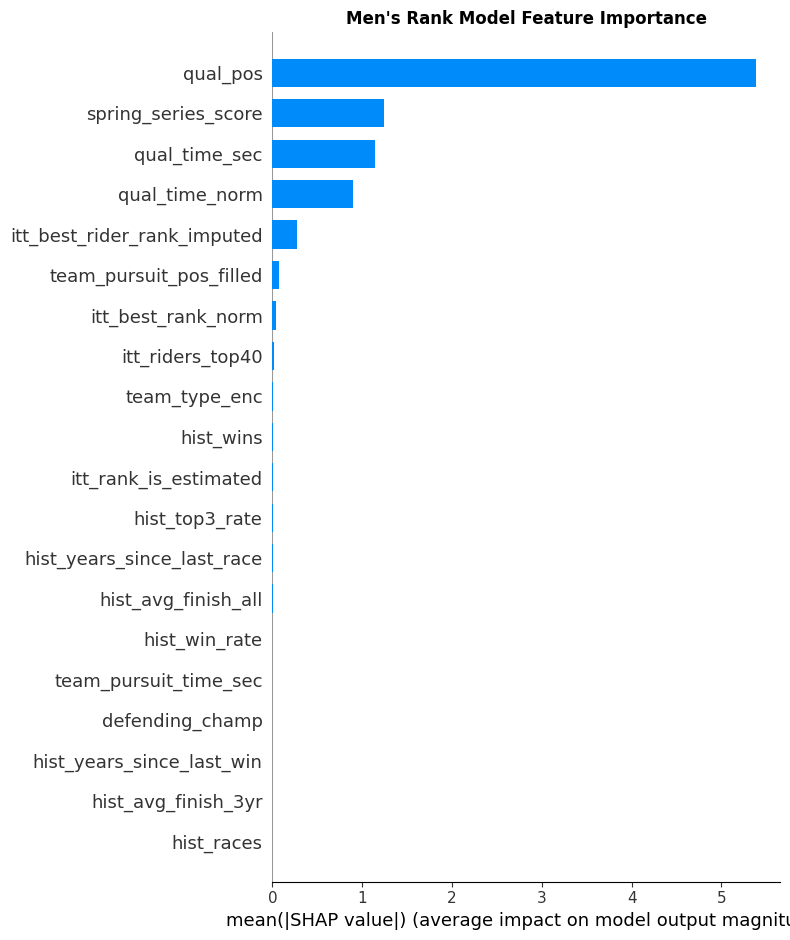

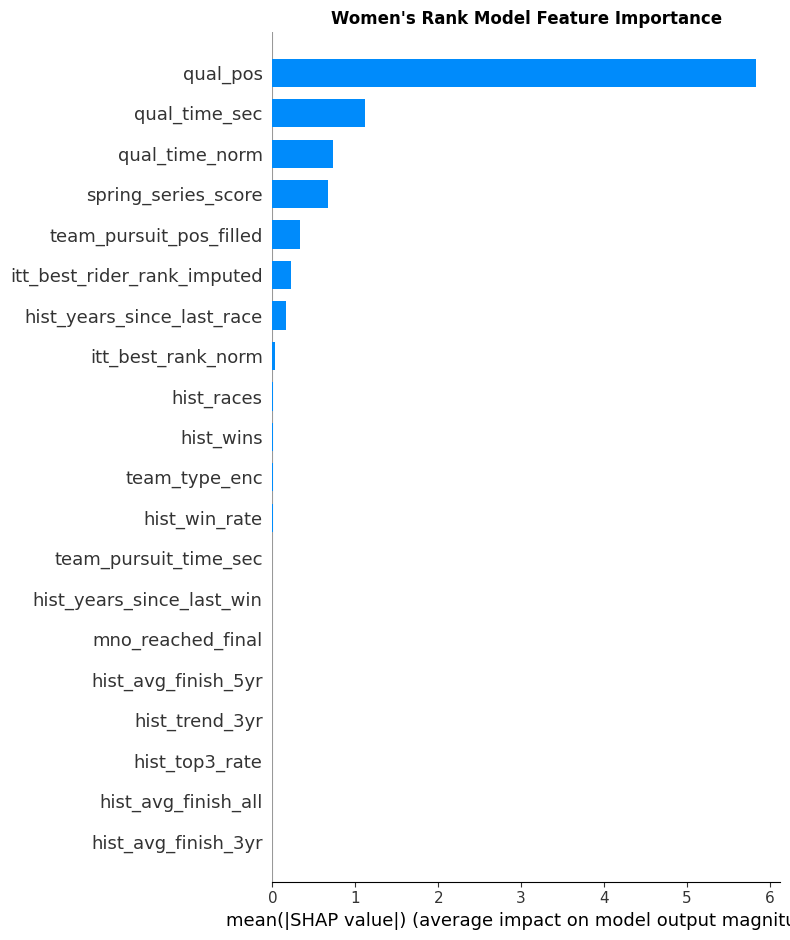

In [27]:
def shap_bar(model, df, features, title):
    explainer = shap.TreeExplainer(model)
    sv = explainer.shap_values(df[features])
    plt.figure(figsize=(10, 6))
    shap.summary_plot(sv, df[features], plot_type='bar', show=False)
    plt.title(title, fontweight='bold')
    plt.tight_layout()
    plt.savefig(title.lower().replace(" ", "_").replace("'", "") + '.png',
                dpi=150, bbox_inches='tight')
    plt.show()


def shap_beeswarm(model, df, features, title):
    explainer = shap.TreeExplainer(model)
    sv = explainer.shap_values(df[features])
    plt.figure(figsize=(10, 7))
    shap.summary_plot(sv, df[features], show=False)
    plt.title(title, fontweight='bold')
    plt.tight_layout()
    plt.savefig('beeswarm_' + title.lower().replace(" ", "_").replace("'", "") + '.png',
                dpi=150, bbox_inches='tight')
    plt.show()


shap_bar(model_m_reg, df_m, FEATURES_M, "Men's Rank Model Feature Importance")
shap_bar(model_w_reg, df_w, FEATURES_W, "Women's Rank Model Feature Importance")

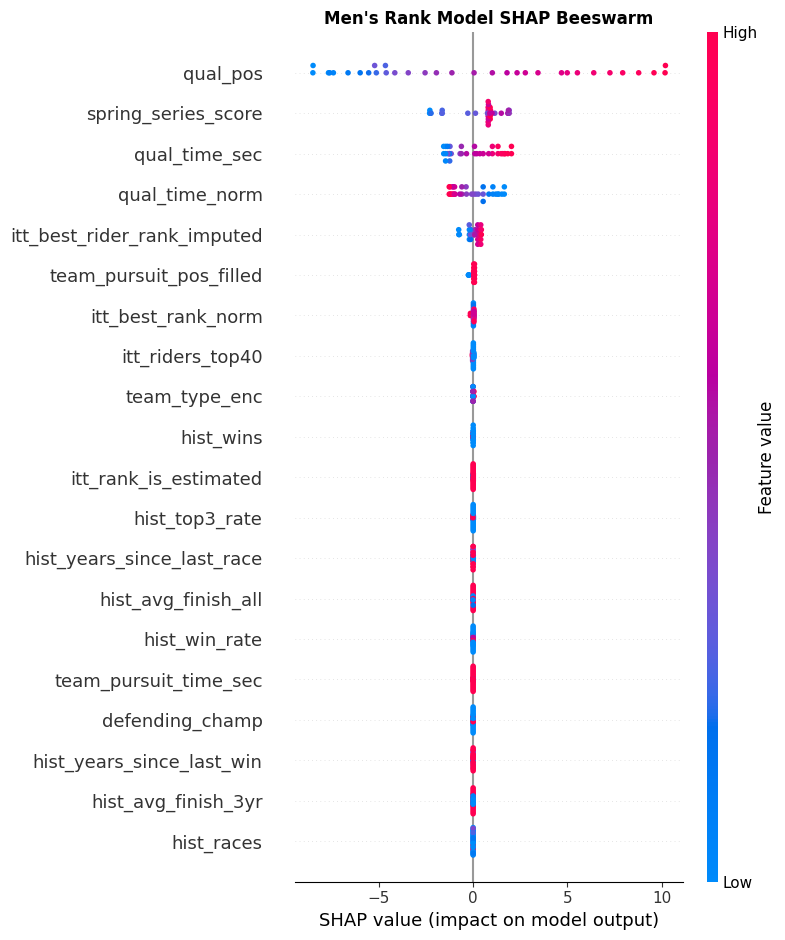

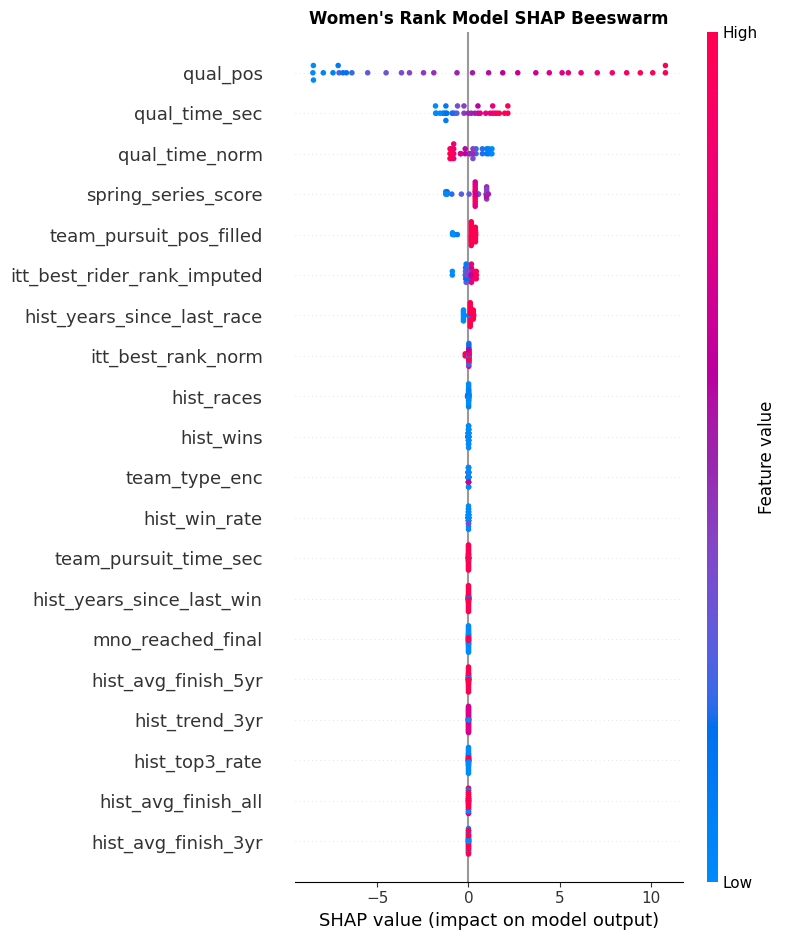

In [28]:
shap_beeswarm(model_m_reg, df_m, FEATURES_M, "Men's Rank Model SHAP Beeswarm")
shap_beeswarm(model_w_reg, df_w, FEATURES_W, "Women's Rank Model SHAP Beeswarm")

## 8. Hyperparameter Tuning (Optional)

In [17]:
TUNE = True  # flip to True to run

if TUNE:
    param_grid = {
        'n_estimators':     [50, 100, 200],
        'max_depth':        [2, 3, 4],
        'learning_rate':    [0.01, 0.05, 0.1],
        'min_child_weight': [2, 3, 5],
        'reg_alpha':        [0.1, 0.5, 1.0],
    }
    for df, features, name in [
        (df_m, FEATURES_M, "Men's"),
        (df_w, FEATURES_W, "Women's"),
    ]:
        gs = GridSearchCV(
            XGBRegressor(random_state=SEED, verbosity=0),
            param_grid,
            cv=LeaveOneOut(),
            scoring='neg_mean_absolute_error',
            n_jobs=-1,
        )
        gs.fit(df[features].values, df['target_rank'].values)
        print(f"{name} best params: {gs.best_params_}")
        print(f"{name} best LOO MAE: {-gs.best_score_:.2f}\n")
else:
    print("Tuning skipped. Set TUNE = True to run.")

Men's best params: {'learning_rate': 0.05, 'max_depth': 4, 'min_child_weight': 2, 'n_estimators': 200, 'reg_alpha': 0.1}
Men's best LOO MAE: 1.16

Women's best params: {'learning_rate': 0.05, 'max_depth': 4, 'min_child_weight': 2, 'n_estimators': 200, 'reg_alpha': 0.5}
Women's best LOO MAE: 1.12



## 9. Export Predictions

In [29]:
men_final.to_csv('little500_2026_men_predictions.csv', index=False)
women_final.to_csv('little500_2026_women_predictions.csv', index=False)

print("Exported.\n")
print("Men's predicted podium:")
print(men_final[['team','ensemble_rank','top5_prob']].head(5).to_string(index=False))
print("\nWomen's predicted podium:")
print(women_final[['team','ensemble_rank','top5_prob']].head(5).to_string(index=False))

Exported.

Men's predicted podium:
               team  ensemble_rank  top5_prob
            Cutters              1   0.784567
Sigma Alpha Epsilon              2   0.784567
    Black Key Bulls              3   0.784567
    Phi Gamma Delta              4   0.784567
  Sigma Phi Epsilon              5   0.784567

Women's predicted podium:
             team  ensemble_rank  top5_prob
            Teter              1   0.757669
  Alpha Chi Omega              2   0.757669
Kappa Alpha Theta              3   0.757669
      Delta Gamma              4   0.757669
        Novus (W)              5   0.757669


## 10. Post-Race Evaluation


In [ ]:
def evaluate(final_df, csv_path, label):
    actual = pd.read_csv(csv_path)[['team', 'actual_finish_2026']].dropna()
    merged = final_df.merge(actual, on='team')

    mae = mean_absolute_error(merged['actual_finish_2026'], merged['ensemble_rank'])
    top5_actual = (merged['actual_finish_2026'] <= 5).astype(int)
    top5_pred   = (merged['top5_prob'] >= 0.5).astype(int)
    acc = accuracy_score(top5_actual, top5_pred)

    print(f"\n{label}")
    print(f"  Rank MAE:       {mae:.2f} positions")
    print(f"  Top-5 Accuracy: {acc:.3f}")
    print(
        merged[['team','ensemble_rank','actual_finish_2026','top5_prob']]
        .sort_values('actual_finish_2026')
        .head(10)
        .to_string(index=False)
    )


# Uncomment after filling actual_finish_2026:
# evaluate(men_final,   MEN_CSV,   "MEN'S RACE")
# evaluate(women_final, WOMEN_CSV, "WOMEN'S RACE")
print("Fill actual_finish_2026 in both XGB CSVs, re-run notebook, then uncomment above.")